
HỆ THỐNG GIẢI TOÁN (TRANSFORMER)
CÂU HỎI: Điền số vào các ô ? sau



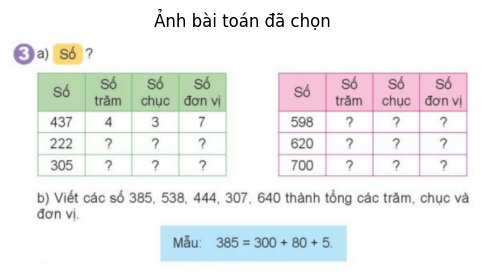

--- Đã nhận diện ảnh: 3.png ---

Đang suy luận lời giải...
LỜI GIẢI DỰ ĐOÁN:
- Số nào chia cho 5 thì được một số có chữ số tận cùng là 0 thì chia hết cho 5. - Nếu một số có chữ số tận cùng là 0, ta có thể cùng xóa một chữ số 0 ở tận cùng của số chia và số bị chia, rồi chia cho 5.

CÂU HỎI: Chum nào có phép tính lớn hơn 150?



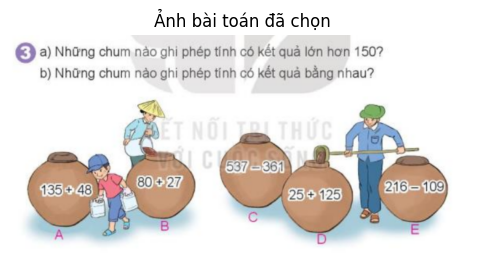

--- Đã nhận diện ảnh: 16.png ---

Đang suy luận lời giải...
LỜI GIẢI DỰ ĐOÁN:
So sánh các số có phép tính lớn hơn 5 nhưng bé hơn 5 nhưng bé hơn 3. Ta có: 23 > 20 > 13 > 13 > 5 Vậy bình lớn hơn bình thường.

CÂU HỎI: Phép nhân 3


Đang suy luận lời giải...
LỜI GIẢI DỰ ĐOÁN:
Đáp án đúng là: C 3 × 4 = 12 Vậy 3 × 4 = 12

CÂU HỎI: 3 x 2 - 10 bằng mấy


Đang suy luận lời giải...
LỜI GIẢI DỰ ĐOÁN:
Đáp án đúng là: A 3 x 2 - 10 = 3 x 2 - 10 = 3 x 2 - 10 = 3 x 2 - 10 = 3 x 2 - 10 = 3 x 2 - 10 = 3 x 3 - 10 = 3 x 2 - 10 = 3 x 2 - 10 = 3 x 2 - 10 = 5

CÂU HỎI: Cho chu vi hình tam giác ABC là 12, với cạnh AB là 3, AC là 4. Hỏi BC dài bao nhiêu?


Đang suy luận lời giải...
LỜI GIẢI DỰ ĐOÁN:
Đáp án đúng là: A Ta có: 12 + 3 + 4 = 13 ( cm ) Vậy đáp án đúng là: 13

CÂU HỎI: Cho chu vi hình tam giác ABC là 12, với cạnh AB là 3, AC là 4. Hỏi cạnh BC dài bao nhiêu?


Đang suy luận lời giải...
LỜI GIẢI DỰ ĐOÁN:
Đáp án đúng là: A Cạnh AD dài là: 12 + 3 + 4 = 19 ( cm ) Đáp số: 19 cm

CÂU HỎI: 


Đang suy luận 

In [4]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import json
import re
import math
import torch.nn as nn
from pathlib import Path
from collections import OrderedDict

# ==========================================
# 1. KIẾN TRÚC MÔ HÌNH (Y hệt transformer.ipynb)
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerDecoderModel(nn.Module):
    def __init__(self, vocab_size, d_model=512, nhead=16, num_layers=8, dim_feedforward=2048):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward, 
            batch_first=True
        )
        self.decoder = nn.TransformerEncoder(layer, num_layers)
        self.fc = nn.Linear(d_model, vocab_size)
        self.d_model = d_model

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        return mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))

    def forward(self, x):
        seq_len = x.size(1)
        tgt_mask = self.generate_square_subsequent_mask(seq_len).to(x.device)
        emb = self.embedding(x) * math.sqrt(self.d_model)
        emb = self.pos_encoder(emb)
        out = self.decoder(emb, mask=tgt_mask, is_causal=True) 
        return self.fc(out)

# ==========================================
# 2. HÀM TIỀN XỬ LÝ
# ==========================================
def preprocess_text(text):
    if not text:
        return []
    text = re.sub(r'\s+', ' ', str(text)).strip()
    tokens = text.split()
    normalized = []
    for tok in tokens:
        # Sửa lỗi Regex: Đặt dấu '-' ở cuối
        t = re.sub(r'([=+\-*/×÷()\-])', r' \1 ', tok.strip())
        normalized.extend([x for x in t.split() if x])
    return normalized

# ==========================================
# 3. TẢI MÔ HÌNH VÀ TỪ ĐIỂN
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
VOCAB_PATH = './vocab.json' 
MODEL_PATH = './best_model.pt'

if not Path(VOCAB_PATH).exists():
    raise FileNotFoundError(f"Không tìm thấy file vocab tại {VOCAB_PATH}")

with open(VOCAB_PATH, 'r', encoding='utf-8') as f:
    vocab = json.load(f)
id_to_vocab = {v: k for k, v in vocab.items()}

# Tải trọng số và xử lý DataParallel[cite: 1]
state_dict = torch.load(MODEL_PATH, map_location=device)
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k 
    new_state_dict[name] = v

final_vocab_size = new_state_dict['embedding.weight'].size(0)

model = TransformerDecoderModel(
    vocab_size=final_vocab_size,
    d_model=512, 
    nhead=16, 
    num_layers=8, 
    dim_feedforward=2048
).to(device)

model.load_state_dict(new_state_dict)
model.eval()

# ==========================================
# 4. HÀM DỰ ĐOÁN VÀ GIAO DIỆN CHỌN ẢNH[cite: 1]
# ==========================================
def generate_solution(question, max_len=128):
    prompt = f"Câu hỏi: {question} Giải:"
    tokens = preprocess_text(prompt)
    
    sos_idx = vocab.get('<SOS>', 2)
    eos_idx = vocab.get('<EOS>', 3)
    unk_idx = vocab.get('<UNK>', 1)
    
    input_ids = [sos_idx] + [vocab.get(t, unk_idx) for t in tokens]
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    
    generated_ids = []
    with torch.no_grad():
        for _ in range(max_len):
            outputs = model(input_tensor)
            next_token_id = torch.argmax(outputs[0, -1, :]).item()
            if next_token_id == eos_idx or next_token_id >= final_vocab_size: 
                break
            generated_ids.append(next_token_id)
            input_tensor = torch.cat([input_tensor, torch.tensor([[next_token_id]], device=device)], dim=1)
            
    return " ".join([id_to_vocab.get(idx, f"[{idx}]") for idx in generated_ids])

def run_predict():
    print("\n" + "="*40)
    print("HỆ THỐNG GIẢI TOÁN (TRANSFORMER)")
    print("="*40)
    
    while True:
        user_q = input("\nNhập câu hỏi (hoặc 'exit' để thoát): ")
        if user_q.lower() == 'exit': break
        print(f"CÂU HỎI: {user_q}\n")
        # Thêm phần chọn ảnh
        img_path = input("Kéo ảnh vào đây hoặc nhập đường dẫn (Enter để bỏ qua): ").strip()
        # Xóa dấu nháy kép nếu người dùng kéo thả file vào terminal
        img_path = img_path.replace('"', '').replace("'", "")
        
        if img_path and Path(img_path).exists():
            try:
                img = Image.open(img_path)
                plt.figure(figsize=(6, 4))
                plt.imshow(img)
                plt.title("Ảnh bài toán đã chọn")
                plt.axis('off')
                plt.show()
                print(f"--- Đã nhận diện ảnh: {Path(img_path).name} ---")
            except Exception as e:
                print(f"Lỗi hiển thị ảnh: {e}")
        elif img_path:
            print("Cảnh báo: Đường dẫn ảnh không tồn tại.")

        print("\nĐang suy luận lời giải...")
        ans = generate_solution(user_q)
        print(f"LỜI GIẢI DỰ ĐOÁN:\n{ans}\n")

if __name__ == "__main__":
    run_predict()